# Warm-start headline benchmark analysis

Reads `../results_benchmark_warmstart.csv` (produced by `benchmark.py`) and produces:

1. Coverage check (which `(scenario, method)` cells are populated).
2. Headline summary table for `tab:results-summary` in `5_results.tex`.
3. &gamma; distribution per `(scenario, method)` &mdash; figure for &sect;5.3 / &sect;5.4.
4. Warm-start vs training contribution &mdash; how often does the optimiser actually improve on the warm-start?
5. Spike count vs &gamma; scatter &mdash; the count-vs-timing tradeoff.
6. Per-parameter recovery error &mdash; which parameters are recovered cleanly, which aren't.
7. Wall time per method.
8. Failure-mode inventory for &sect;5.5.

PDF outputs go to `../../2_thesis/figures/`. The notebook is safe to run against a partial CSV; cells that lack data print a warning and continue.

## 1. Load & coverage

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV = Path('../results_benchmark_warmstart.csv')
FIG_DIR = Path('../../2_thesis/figures/')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV)
print(f'rows: {len(df)}')
print(f'scenarios: {sorted(df.scenario.unique())}')
print(f'methods:   {sorted(df.method.unique())}')
print(f'kept_source: {df.kept_source.value_counts(dropna=False).to_dict()}')
df.head(3)

rows: 900
scenarios: ['adaptation', 'initial_bursting', 'tonic']
methods:   ['grad_guarino', 'grad_vanrossum', 'nm_guarino']
kept_source: {'training': 488, 'warmstart': 412}


,run_id,scenario,init_idx,method,final_gamma,n_spikes_gt,n_spikes_sim,warmstart_loss,train_best_loss,train_final_loss,...,warmstart_params_json,final_params_json,gt_params_json,timestamp_iso,norm_err_C_m,norm_err_g_L,norm_err_E_L,norm_err_v_T,norm_err_delta_T,norm_err_v_reset
0,tonic_000_grad_guarino,tonic,0,grad_guarino,0.131944,9,9,0.516659,0.597041,0.597041,...,"{""C_m"": 95.08516882859402, ""g_L"": 12.200828977...","{""C_m"": 95.08516882859402, ""g_L"": 12.200828977...","{""C_m"": 200.0, ""g_L"": 10.0, ""E_L"": -70.0, ""v_T...",2026-04-28T18:16:45.267245+00:00,0.456151,0.275104,0.370896,0.155070,0.124635,0.071679
1,tonic_000_grad_vanrossum,tonic,0,grad_vanrossum,0.131944,9,9,4.482135,4.625020,23.405996,...,"{""C_m"": 95.08516882859402, ""g_L"": 12.200828977...","{""C_m"": 95.08516882859402, ""g_L"": 12.200828977...","{""C_m"": 200.0, ""g_L"": 10.0, ""E_L"": -70.0, ""v_T...",2026-04-28T18:16:46.751693+00:00,0.456151,0.275104,0.370896,0.155070,0.124635,0.071679
2,tonic_000_nm_guarino,tonic,0,nm_guarino,0.652778,9,9,0.516659,0.370939,0.370939,...,"{""C_m"": 95.08516882859402, ""g_L"": 12.200828977...","{""C_m"": 94.81649916045066, ""g_L"": 11.827442782...","{""C_m"": 200.0, ""g_L"": 10.0, ""E_L"": -70.0, ""v_T...",2026-04-28T18:16:47.328577+00:00,0.457320,0.228430,0.348811,0.145038,0.132926,0.028203


In [2]:
# Coverage: how many runs per (scenario, method)?
coverage = (df.groupby(['scenario', 'method']).size()
              .unstack('method', fill_value=0))
print(coverage)

n_inits_expected = 100  # benchmark.py N_INITS
missing = (coverage < n_inits_expected).sum().sum()
if missing:
    print(f'\n[partial run] {missing} (scenario, method) cells under-filled '
          f'(expected {n_inits_expected} per cell)')

method            grad_guarino  grad_vanrossum  nm_guarino
scenario                                                  
adaptation                 100             100         100
initial_bursting           100             100         100
tonic                      100             100         100


## 2. Headline summary table

Median &gamma; (IQR), median final_loss, fraction of runs where training improved on warm-start, median spike-count ratio. This is what populates `tab:results-summary` (`5_results.tex:106-118`).

An extra row labelled `warmstart_only` shows the warm-start baseline that any optimiser must beat &mdash; computed by treating each row's `warmstart_loss` as if it had been the final result, with the corresponding warm-start params giving the &gamma;. (We don't have warm-start &gamma; directly in the CSV; computing it would require re-simulation. As a proxy we use the rows where `kept_source == 'warmstart'` and read `final_gamma`, which is the &gamma; achieved by warm-start params alone.)

In [3]:
def iqr_str(s, pct=2):
    s = s.dropna()
    if len(s) == 0:
        return 'n/a'
    return f'{s.median():.{pct}f} [{s.quantile(0.25):.{pct}f}, {s.quantile(0.75):.{pct}f}]'

def spike_ratio_str(df_sub):
    df_sub = df_sub[(df_sub.n_spikes_gt > 0)]
    if len(df_sub) == 0:
        return 'n/a'
    ratio = df_sub.n_spikes_sim / df_sub.n_spikes_gt
    return f'{ratio.median():.2f} [{ratio.quantile(0.25):.2f}, {ratio.quantile(0.75):.2f}]'

rows = []
for scenario in sorted(df.scenario.unique()):
    sub = df[df.scenario == scenario]
    for method in sorted(sub.method.unique()):
        runs = sub[sub.method == method]
        useful_frac = (runs.kept_source == 'training').mean() if len(runs) else float('nan')
        rows.append({
            'scenario': scenario,
            'method': method,
            'n': len(runs),
            'gamma_median_iqr': iqr_str(runs.final_gamma),
            'final_loss_median': f'{runs.final_loss.median():.3g}' if len(runs) else 'n/a',
            'training_improves_frac': f'{useful_frac:.0%}',
            'spike_ratio_sim/gt': spike_ratio_str(runs),
        })
summary = pd.DataFrame(rows)
summary

,scenario,method,n,gamma_median_iqr,final_loss_median,training_improves_frac,spike_ratio_sim/gt
0,adaptation,grad_guarino,100,"0.11 [-0.21, 0.50]",0.679,42%,"1.00 [0.80, 1.00]"
1,adaptation,grad_vanrossum,100,"0.05 [-0.17, 0.25]",4.11,46%,"0.80 [0.60, 1.00]"
2,adaptation,nm_guarino,100,"0.25 [-0.21, 0.50]",0.513,97%,"1.00 [0.80, 1.00]"
3,initial_bursting,grad_guarino,100,"0.01 [-0.20, 0.52]",0.455,29%,"1.00 [1.00, 1.14]"
4,initial_bursting,grad_vanrossum,100,"0.00 [-0.19, 0.42]",4.5,26%,"1.00 [0.86, 1.14]"
5,initial_bursting,nm_guarino,100,"0.21 [-0.24, 0.80]",0.346,93%,"1.00 [1.00, 1.14]"
6,tonic,grad_guarino,100,"0.02 [-0.50, 0.19]",0.501,17%,"1.00 [0.89, 1.00]"
7,tonic,grad_vanrossum,100,"0.01 [-0.42, 0.31]",4.98,46%,"1.00 [0.86, 1.11]"
8,tonic,nm_guarino,100,"-0.22 [-0.56, 0.31]",0.284,92%,"1.00 [1.00, 1.00]"


In [4]:
# Warm-start-only baseline: per (scenario, method), median gamma when kept_source=='warmstart'
ws_only = (df[df.kept_source == 'warmstart']
             .groupby(['scenario', 'method'])
             .agg(n=('final_gamma', 'size'),
                  gamma_median=('final_gamma', 'median'),
                  gamma_q25=('final_gamma', lambda s: s.quantile(0.25)),
                  gamma_q75=('final_gamma', lambda s: s.quantile(0.75)))
             .reset_index())
print('Warm-start-only \u0393 (rows where optimiser fell back):')
ws_only

Warm-start-only Γ (rows where optimiser fell back):


,scenario,method,n,gamma_median,gamma_q25,gamma_q75
0,adaptation,grad_guarino,58,0.000000,-0.250000,0.300595
1,adaptation,grad_vanrossum,54,0.186335,-0.158897,0.317460
2,adaptation,nm_guarino,3,0.250000,0.000000,0.283730
3,initial_bursting,grad_guarino,71,0.007937,-0.388889,0.603175
4,initial_bursting,grad_vanrossum,74,0.079264,-0.302680,0.541176
5,initial_bursting,nm_guarino,7,-0.047059,-0.172350,0.007937
6,tonic,grad_guarino,83,0.020761,-0.388889,0.219693
7,tonic,grad_vanrossum,54,0.189743,-0.041667,0.464638
8,tonic,nm_guarino,8,0.131944,-0.085069,0.262153


In [5]:
# LaTeX-formatted summary block — paste into 5_results.tex tab:results-summary.
def fmt_row_tex(scenario, method, runs):
    g = runs.final_gamma.dropna()
    if len(g) == 0:
        return f'{scenario} & {method} & n/a & n/a \\\\'
    g_med = g.median()
    g_iqr = f'[{g.quantile(0.25):.2f}, {g.quantile(0.75):.2f}]'
    n_gt = runs.n_spikes_gt.median() if (runs.n_spikes_gt > 0).any() else 0
    n_sim = runs.n_spikes_sim.median()
    return f'{scenario} & {method.replace("_","\\_")} & {n_sim:.0f}/{n_gt:.0f} & {g_med:.2f} {g_iqr} \\\\'

print('% --- LaTeX rows for tab:results-summary ---')
for scenario in sorted(df.scenario.unique()):
    for method in sorted(df.method.unique()):
        runs = df[(df.scenario == scenario) & (df.method == method)]
        if len(runs) > 0:
            print(fmt_row_tex(scenario, method, runs))

% --- LaTeX rows for tab:results-summary ---
adaptation & grad\_guarino & 5/5 & 0.11 [-0.21, 0.50] \\
adaptation & grad\_vanrossum & 4/5 & 0.05 [-0.17, 0.25] \\
adaptation & nm\_guarino & 5/5 & 0.25 [-0.21, 0.50] \\
initial_bursting & grad\_guarino & 7/7 & 0.01 [-0.20, 0.52] \\
initial_bursting & grad\_vanrossum & 7/7 & 0.00 [-0.19, 0.42] \\
initial_bursting & nm\_guarino & 7/7 & 0.21 [-0.24, 0.80] \\
tonic & grad\_guarino & 9/9 & 0.02 [-0.50, 0.19] \\
tonic & grad\_vanrossum & 9/9 & 0.01 [-0.42, 0.31] \\
tonic & nm\_guarino & 9/9 & -0.22 [-0.56, 0.31] \\


## 3. &gamma; distribution per (scenario, method)

Headline figure for &sect;5.3 / &sect;5.4. Boxplot or violin per cell, with the &gamma; = 0.5 success threshold and the &gamma; &approx; 0.82 SOTA-Jolivet line annotated.

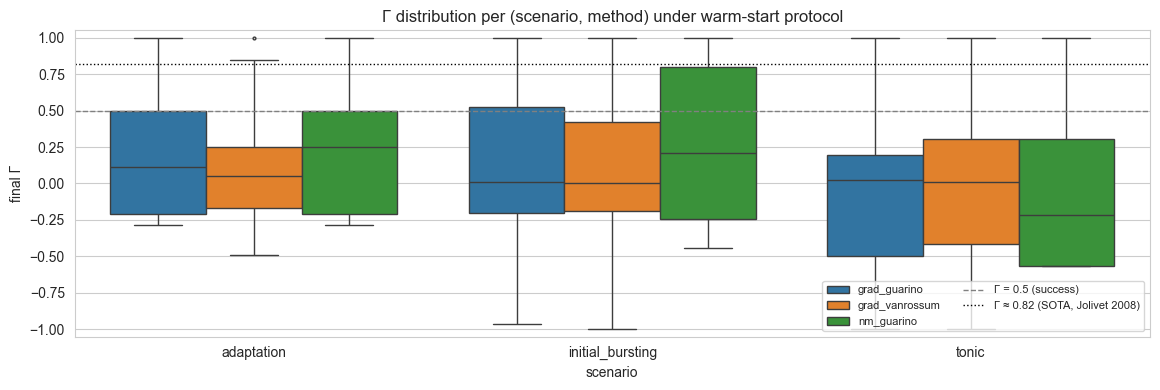

In [6]:
scenarios = sorted(df.scenario.unique())
methods = sorted(df.method.unique())

fig, ax = plt.subplots(figsize=(max(6, 1.3 * len(scenarios) * len(methods)), 4))
sns.boxplot(data=df, x='scenario', y='final_gamma', hue='method',
            order=scenarios, hue_order=methods, ax=ax,
            showfliers=True, fliersize=2)
ax.axhline(0.5, ls='--', color='gray', lw=1, label='\u0393 = 0.5 (success)')
ax.axhline(0.82, ls=':', color='black', lw=1, label='\u0393 \u2248 0.82 (SOTA, Jolivet 2008)')
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('scenario'); ax.set_ylabel('final \u0393')
ax.set_title('\u0393 distribution per (scenario, method) under warm-start protocol')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'warmstart_gamma_boxplot.pdf', bbox_inches='tight')
plt.show()

## 4. Warm-start vs training contribution

How often does each method actually improve on the warm-start it receives? `kept_source == 'training'` means the optimiser found a strictly lower loss; `kept_source == 'warmstart'` means it didn't (and the runner kept warm-start params per `_keep_better`).

Fraction kept_source == training (optimiser improved on warm-start):
method            grad_guarino  grad_vanrossum  nm_guarino
scenario                                                  
adaptation                0.42            0.46        0.97
initial_bursting          0.29            0.26        0.93
tonic                     0.17            0.46        0.92


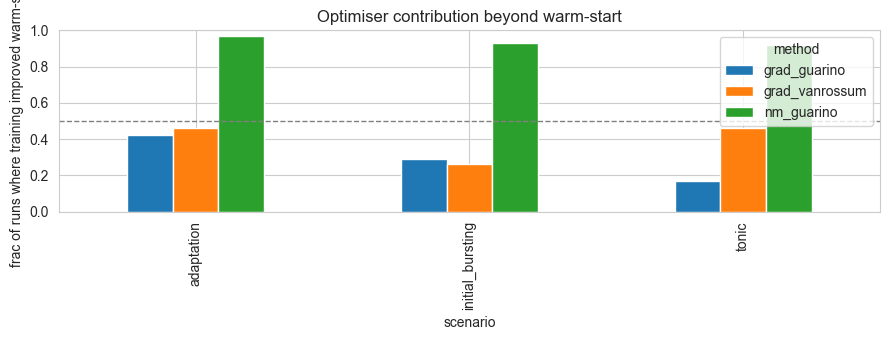

In [7]:
kept = (df.groupby(['scenario', 'method', 'kept_source']).size()
          .unstack('kept_source', fill_value=0))
kept_pct = kept.div(kept.sum(axis=1), axis=0)
print('Fraction kept_source == training (optimiser improved on warm-start):')
print(kept_pct.get('training', pd.Series(dtype=float)).unstack('method'))

fig, ax = plt.subplots(figsize=(max(6, 1.0 * len(scenarios) * len(methods)), 3.5))
kept_pct.get('training', pd.Series(dtype=float)).unstack('method')[methods].plot(
    kind='bar', ax=ax
)
ax.set_ylabel('frac of runs where training improved warm-start')
ax.set_xlabel('scenario'); ax.set_ylim(0, 1.0)
ax.axhline(0.5, ls='--', color='gray', lw=1)
ax.set_title('Optimiser contribution beyond warm-start')
plt.tight_layout()
fig.savefig(FIG_DIR / 'warmstart_training_contribution.pdf', bbox_inches='tight')
plt.show()

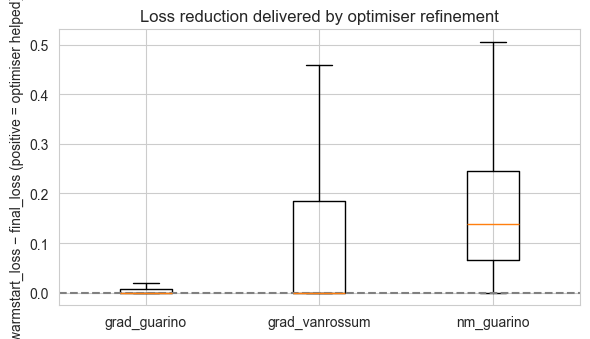

In [8]:
# Loss delta: warmstart_loss - final_loss, per method.
# >0 = optimiser helped, =0 = fell back, <0 cannot happen by _keep_better invariant.
df['loss_delta'] = df.warmstart_loss - df.final_loss
fig, ax = plt.subplots(figsize=(max(6, 1.3 * len(methods)), 3.5))
data = [df[df.method == m].loss_delta.dropna() for m in methods]
ax.boxplot(data, tick_labels=methods, showfliers=False)
ax.axhline(0, ls='--', color='gray')
ax.set_ylabel('warmstart_loss \u2212 final_loss (positive = optimiser helped)')
ax.set_title('Loss reduction delivered by optimiser refinement')
plt.tight_layout()
fig.savefig(FIG_DIR / 'warmstart_loss_delta.pdf', bbox_inches='tight')
plt.show()

## 5. Spike count vs &gamma; scatter

Many gradient methods recover spike *count* without spike *timing*. This scatter shows the count-vs-timing tradeoff: spike-count ratio (sim/gt) on the x axis, &gamma; on the y axis. Methods clustered at (1, near-1) work; clustered at (1, ~0) match counts but not timing; at (0, 0) collapsed to non-spiking; at (>>1, ~0) over-spike.

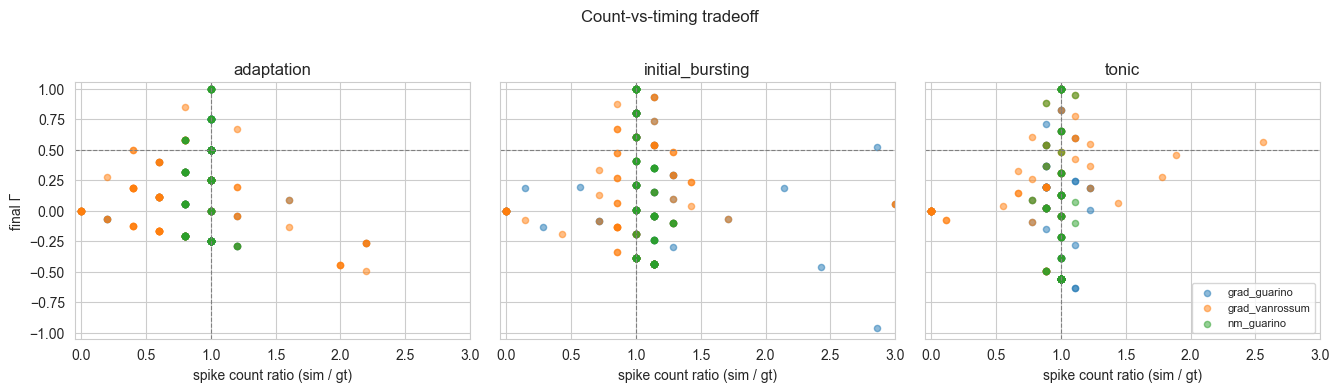

In [9]:
df_plot = df[df.n_spikes_gt > 0].copy()
df_plot['spike_ratio'] = df_plot.n_spikes_sim / df_plot.n_spikes_gt

fig, axes = plt.subplots(1, len(scenarios), figsize=(4.5 * len(scenarios), 3.8), sharey=True)
if len(scenarios) == 1:
    axes = [axes]
for ax, scenario in zip(axes, scenarios):
    sub = df_plot[df_plot.scenario == scenario]
    for method, color in zip(methods, sns.color_palette('tab10', n_colors=len(methods))):
        s = sub[sub.method == method]
        ax.scatter(s.spike_ratio, s.final_gamma, alpha=0.5, s=20, label=method, color=color)
    ax.axvline(1.0, ls='--', color='gray', lw=0.8)
    ax.axhline(0.5, ls='--', color='gray', lw=0.8)
    ax.set_xlabel('spike count ratio (sim / gt)')
    ax.set_title(scenario)
    ax.set_xlim(-0.05, 3.0)
    ax.set_ylim(-1.05, 1.05)
axes[0].set_ylabel('final \u0393')
axes[-1].legend(loc='lower right', fontsize=8)
fig.suptitle('Count-vs-timing tradeoff', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'warmstart_count_vs_gamma.pdf', bbox_inches='tight')
plt.show()

## 6. Per-parameter recovery error

`norm_err_X = |final_X - gt_X| / (bound_max - bound_min)` is the bounds-normalised parameter recovery error. 0 = perfect, 1 = worst-case. This figure tells us *which* parameters each method gets right or wrong.

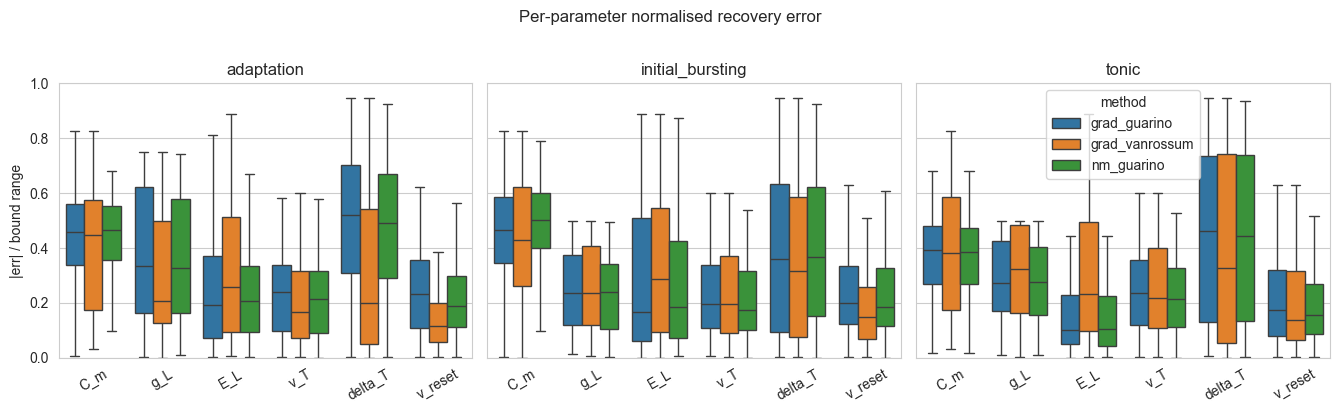

In [10]:
param_cols = [c for c in df.columns if c.startswith('norm_err_')]
param_names = [c.replace('norm_err_', '') for c in param_cols]

long = df.melt(id_vars=['scenario', 'method'], value_vars=param_cols,
               var_name='param', value_name='norm_err')
long['param'] = long['param'].str.replace('norm_err_', '')

fig, axes = plt.subplots(1, len(scenarios), figsize=(4.5 * len(scenarios), 4), sharey=True)
if len(scenarios) == 1:
    axes = [axes]
for ax, scenario in zip(axes, scenarios):
    sub = long[long.scenario == scenario]
    sns.boxplot(data=sub, x='param', y='norm_err', hue='method',
                hue_order=methods, ax=ax, showfliers=False)
    ax.set_title(scenario); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 1.0)
    if ax is not axes[0]:
        ax.set_ylabel('')
    if ax is not axes[-1]:
        ax.legend().remove()
axes[0].set_ylabel('|err| / bound range')
fig.suptitle('Per-parameter normalised recovery error', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'warmstart_param_recovery.pdf', bbox_inches='tight')
plt.show()

## 7. Wall-time per method

Computational efficiency comparison &mdash; one of the thesis evaluation metrics.

Wall time per run (seconds):
                count  median  mean   std
method                                   
grad_guarino      300    1.32  1.34  0.10
grad_vanrossum    300    1.49  1.50  0.15
nm_guarino        300    0.60  0.61  0.05


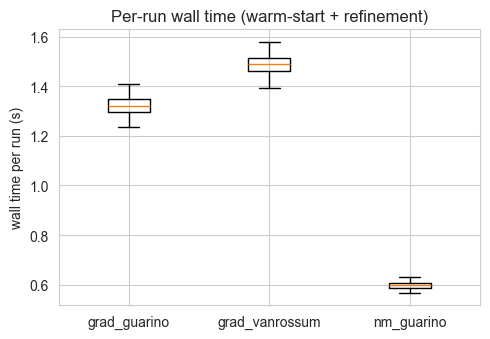

In [11]:
wall_summary = (df.groupby('method')['wall_time_s']
                  .agg(['count', 'median', 'mean', 'std']).round(2))
print('Wall time per run (seconds):')
print(wall_summary)

fig, ax = plt.subplots(figsize=(max(5, 1.5 * len(methods)), 3.5))
data = [df[df.method == m].wall_time_s.dropna() for m in methods]
ax.boxplot(data, tick_labels=methods, showfliers=False)
ax.set_ylabel('wall time per run (s)')
ax.set_title('Per-run wall time (warm-start + refinement)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'warmstart_wall_time.pdf', bbox_inches='tight')
plt.show()

## 8. Failure-mode inventory

For &sect;5.5 (`5_results.tex:122-125`). Each row of the inventory is a paragraph in the chapter.

In [12]:
def inventory_row(label, mask, df=df):
    n = int(mask.sum())
    return {'mode': label, 'n': n, 'pct': f'{n/len(df):.1%}'}

inv = []
inv.append(inventory_row('Non-spiking solution (n_spikes_sim == 0, n_spikes_gt > 0)',
                          (df.n_spikes_sim == 0) & (df.n_spikes_gt > 0)))
inv.append(inventory_row('Phase-inverted timing (\u0393 < 0, n_spikes_sim within \u00b11 of gt)',
                          (df.final_gamma < 0)
                          & ((df.n_spikes_sim - df.n_spikes_gt).abs() <= 1)))
inv.append(inventory_row('Optimiser fell back to warm-start (kept_source == warmstart)',
                          df.kept_source == 'warmstart'))
inv.append(inventory_row('Training NaN-d at epoch 0 (n_iter == 0)',
                          df.n_iter == 0))
inv.append(inventory_row('Training final_loss NaN (numerical blowup)',
                          df.train_final_loss.isna() & (df.n_iter > 0)))
inv.append(inventory_row('Over-spiking (n_spikes_sim > 2 \u00d7 n_spikes_gt)',
                          df.n_spikes_sim > 2 * df.n_spikes_gt))
pd.DataFrame(inv)

,mode,n,pct
0,"Non-spiking solution (n_spikes_sim == 0, n_spi...",45,5.0%
1,"Phase-inverted timing (Γ < 0, n_spikes_sim wit...",277,30.8%
2,Optimiser fell back to warm-start (kept_source...,412,45.8%
3,Training NaN-d at epoch 0 (n_iter == 0),1,0.1%
4,Training final_loss NaN (numerical blowup),0,0.0%
5,Over-spiking (n_spikes_sim > 2 × n_spikes_gt),38,4.2%


In [13]:
# Per-method failure breakdown — where does each method fail?
fail_by_method = []
for method in methods:
    m = df[df.method == method]
    if len(m) == 0:
        continue
    fail_by_method.append({
        'method': method,
        'n': len(m),
        'non_spiking': f'{((m.n_spikes_sim == 0) & (m.n_spikes_gt > 0)).mean():.1%}',
        'phase_inverted': f'{((m.final_gamma < 0) & ((m.n_spikes_sim - m.n_spikes_gt).abs() <= 1)).mean():.1%}',
        'fallback_to_ws': f'{(m.kept_source == "warmstart").mean():.1%}',
        'training_nan': f'{(m.n_iter == 0).mean():.1%}',
        'success_gamma>0.5': f'{(m.final_gamma > 0.5).mean():.1%}',
    })
pd.DataFrame(fail_by_method)

,method,n,non_spiking,phase_inverted,fallback_to_ws,training_nan,success_gamma>0.5
0,grad_guarino,300,4.0%,32.0%,70.7%,0.0%,17.0%
1,grad_vanrossum,300,11.0%,20.0%,60.7%,0.3%,15.7%
2,nm_guarino,300,0.0%,40.3%,6.0%,0.0%,25.3%


## 9. Saved figures

Figures saved to `../../2_thesis/figures/`:

- `warmstart_gamma_boxplot.pdf` &mdash; main &sect;5.3 / &sect;5.4 figure.
- `warmstart_training_contribution.pdf` &mdash; &sect;5.5 (does gradient help?).
- `warmstart_loss_delta.pdf` &mdash; complementary to above.
- `warmstart_count_vs_gamma.pdf` &mdash; count-vs-timing tradeoff figure.
- `warmstart_param_recovery.pdf` &mdash; per-parameter recovery error.
- `warmstart_wall_time.pdf` &mdash; wall-time per method.

Re-run cells against the final CSV when the headline benchmark completes.